In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***1️⃣ Import & Load Dataset***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Ukuran dataset:", X.shape)

Ukuran dataset: (569, 30)


# ***2️⃣ Train-Test Split***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ***3️⃣ Decision Tree***

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Akurasi DecisionTRee:", accuracy_score(y_test, y_pred_dt))

Akurasi DecisionTRee: 0.9473684210526315


# ***4️⃣ Random Forest***

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Akurasi RandoM Forest:", accuracy_score(y_test, y_pred_rf))

Akurasi RandoM Forest: 0.9649122807017544


# ***5️⃣ Gradient Boosting***

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Akurasi Gradient Boosting:", accuracy_score(y_test, y_pred_gb))

Akurasi Gradient Boosting: 0.956140350877193


# ***6️⃣ Perbandingan Model***

In [ ]:
models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for name, pred in models.items():
    print(f"\n{name}")
    print("Akurasi:", accuracy_score(y_test, pred))


Decision Tree
Akurasi: 0.9473684210526315

Random Forest
Akurasi: 0.9649122807017544

Gradient Boosting
Akurasi: 0.956140350877193


# ***7️⃣ 10 Feature Importance (Random Forest)***

In [ ]:
importances = rf.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)
top10 = feat_importance.sort_values(ascending=False).head(10)

print("Top 10 Feature Importance:")
print(top10)

Top 10 Feature Importance:
worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
mean perimeter          0.053270
mean radius             0.048703
mean area               0.047555
worst concavity         0.031802
dtype: float64


**Visualisasi Feature Importance**

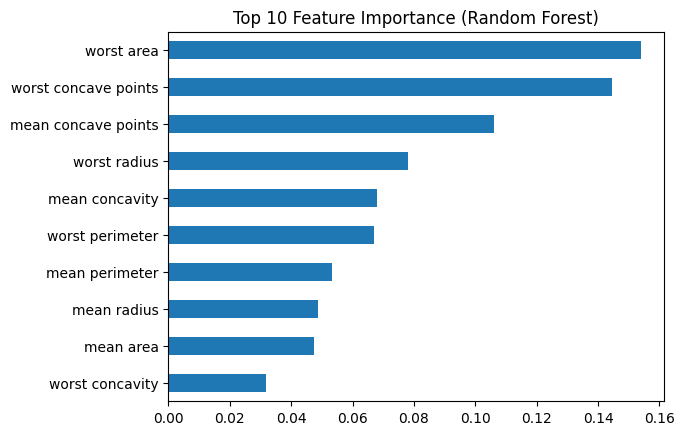

In [ ]:
plt.figure()
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

# ***8️⃣ Eksperimen n_estimators***

In [ ]:
estimators = [10, 50, 100, 200]

print("Pengaruh n_estimators (Random Forest):")

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"n_estimators = {n} | Accuracy = {accuracy_score(y_test, pred)}")

Pengaruh n_estimators (Random Forest):
n_estimators = 10 | Accuracy = 0.956140350877193
n_estimators = 50 | Accuracy = 0.9649122807017544
n_estimators = 100 | Accuracy = 0.9649122807017544
n_estimators = 200 | Accuracy = 0.9649122807017544


# Interpretasi n_estimators


---



* Semakin besar n_estimators → model lebih stabil

* Tapi waktu training lebih lama

* Setelah titik tertentu → kenaikan akurasi kecil (diminishing return)


---
# ***🧠 Kesimpulan***
1. Random Forest menghasilkan akurasi lebih tinggi dibanding Decision Tree karena mengurangi overfitting melalui bagging.

2. Gradient Boosting mampu menyesuaikan error sebelumnya sehingga sering menghasilkan performa terbaik.

3. Penambahan n_estimators meningkatkan stabilitas model, tetapi setelah batas tertentu peningkatan akurasi menjadi kecil.
